# Explore here

In [242]:
!pip install missingno MissForest
!pip install lightgbm
!pip install tqdm
!pip install statsmodels
!pip install shap

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [243]:
import pandas as pd
import missingno as msno
from sklearn.model_selection import train_test_split
from missforest import MissForest
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
import shap
import lightgbm as lgb
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

## Nos contectamos con la data y la convertimos a DF

In [244]:
df = pd.read_csv('/workspaces/jovegom-intro-ml/data/raw/arbnbdataset.csv',index_col="id")
pd.set_option('display.max_columns', None) # mostramos todas las columnas
df


,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
id,,,,,,,,,,,,,,,
2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365
2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaN,NaN,1,365
3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.68,-73.95,Private room,70,2,0,NaN,NaN,2,9
36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70,-73.93,Private room,40,4,0,NaN,NaN,2,36
36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81,-73.95,Entire home/apt,115,10,0,NaN,NaN,1,27


## Valores Unicos

In [245]:
unicos = df.nunique()
unicos


name                              47905
host_id                           37457
host_name                         11452
neighbourhood_group                   5
neighbourhood                       221
latitude                          19048
longitude                         14718
room_type                             3
price                               674
minimum_nights                      109
number_of_reviews                   394
last_review                        1764
reviews_per_month                   937
calculated_host_listings_count       47
availability_365                    366
dtype: int64

No tienemos ninguna columna que tenga valores unicos

## Eliminamos columnas redundantes

In [246]:
df.drop('host_name', axis=1, inplace=True) # Se elimina esta columna ya que es redundate con Host name y necesitamos varibles numericas
df.drop('name', axis=1, inplace=True) #Se elimina esta columna ya que no aporta ninguna categoria a los datos

## Eliminamos filas y columnas duplicadas

In [247]:
# Columnas
df.T.duplicated().sum()
# Filas
df.duplicated().sum()

np.int64(0)

No tenemos columnas y filas duplicadas

## Valores faltantes

In [248]:
faltantes = df.isna().mean()*100
faltantes[faltantes>0]

last_review         20.56
reviews_per_month   20.56
dtype: float64

<Axes: >

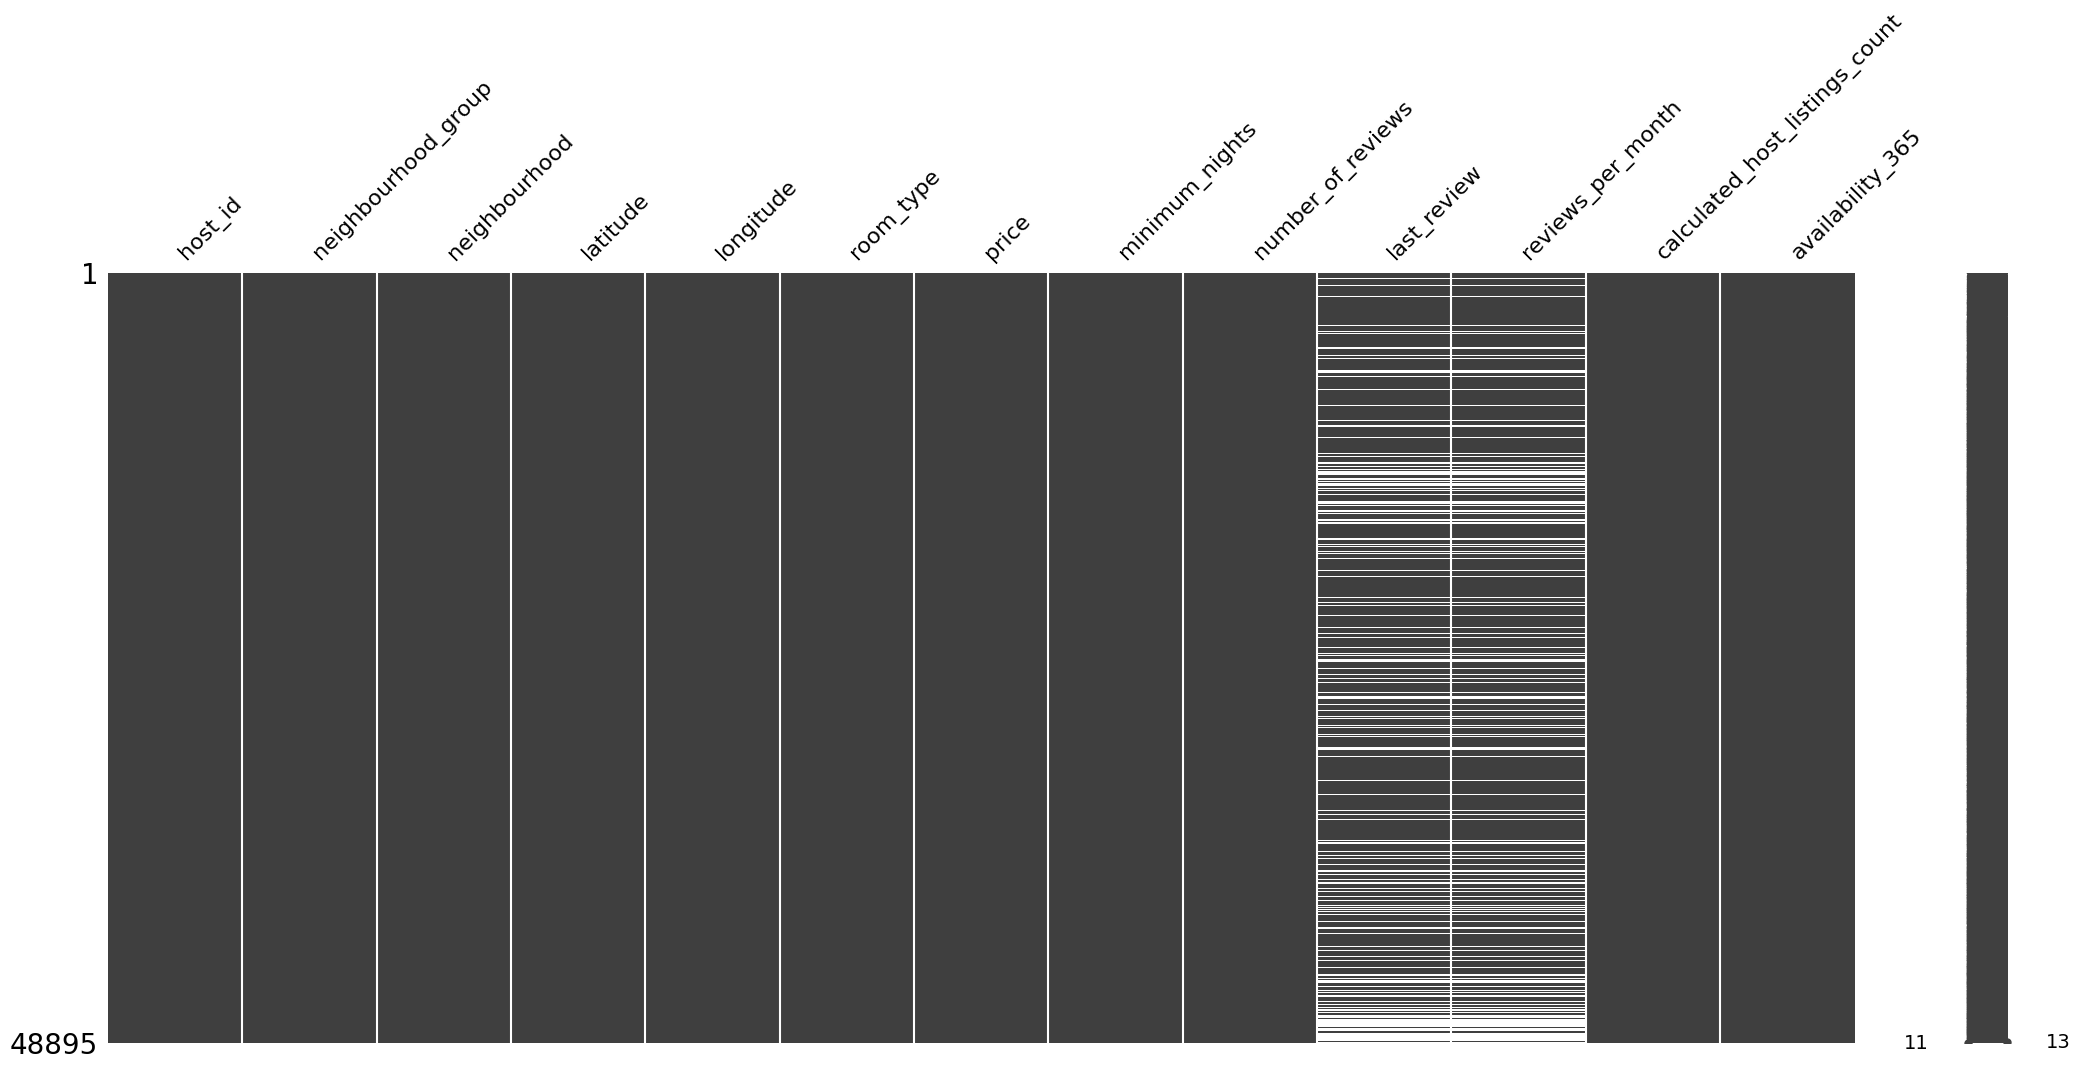

In [249]:
msno.matrix(df)

## Imputar

### Reviews_per_month y last_review    

al analizar la grafica anterior podemos observar que los faltantes son los mismos en ambas variables, y se intuye que esto es debido a que los airbnb son nuevos por ende no tienen reviews.

In [250]:
# Guardamos un Df con los valores que vamos a cambiar en caso de que lo queramos ver en un futuro
df_original=df[['last_review','neighbourhood','neighbourhood_group','room_type',]]
# Creamos una columna binaria 0 si es vivienda nueva y 1 si no
df['vivienda_nueva'] = df['last_review'].map(lambda x: 1 if pd.notna(x) and x != '' else 0) 
# Eliminamos la columna original
df.drop('last_review', axis=1, inplace=True) 
# Remplazamos por 0 los valores Nan en number_of_reviews
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

## Codificar variables categóricas.

In [251]:
encoder = LabelEncoder()
df['neighbourhood'] = encoder.fit_transform(df['neighbourhood'])
df['neighbourhood_group'] = encoder.fit_transform(df['neighbourhood_group'])
df['room_type'] = encoder.fit_transform(df['room_type'])


## Train test split

In [252]:
X= df.drop('price',axis=1)
y= df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,vivienda_nueva
id,,,,,,,,,,,,
25674366,9038810,1,214,40.72,-73.96,0,3,11,0.87,1,1,1
19100971,81745867,2,206,40.85,-73.94,1,2,2,0.16,1,0,1
24209867,1218837,1,13,40.69,-73.96,1,2,0,0.00,2,0,0
22451798,4126686,1,13,40.68,-73.93,0,3,87,4.91,1,267,1
5344850,27698133,3,220,40.75,-73.90,1,5,13,0.25,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
8754339,20261309,2,206,40.85,-73.94,2,1,0,0.00,1,0,0
34383329,53254710,2,34,40.74,-74.00,1,2,4,1.90,1,76,1
30109697,1385157,2,202,40.78,-73.97,0,30,1,0.34,5,261,1


## Outliers

In [253]:
pd.set_option('display.float_format', '{:.2f}'.format)
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
host_id,39116.00,67593557.44,78670917.79,2438.00,7812757.75,30598307.50,107434423.00,274321313.00
neighbourhood_group,39116.00,1.67,0.73,0.00,1.00,2.00,2.00,4.00
neighbourhood,39116.00,107.30,68.73,0.00,51.00,94.00,178.00,220.00
latitude,39116.00,40.73,0.05,40.50,40.69,40.72,40.76,40.91
longitude,39116.00,-73.95,0.05,-74.24,-73.98,-73.96,-73.94,-73.71
room_type,39116.00,0.50,0.54,0.00,0.00,0.00,1.00,2.00
minimum_nights,39116.00,7.14,21.47,1.00,1.00,3.00,5.00,1250.00
number_of_reviews,39116.00,23.33,44.50,0.00,1.00,5.00,24.00,629.00
reviews_per_month,39116.00,1.09,1.60,0.00,0.04,0.37,1.59,58.50
calculated_host_listings_count,39116.00,7.19,33.17,1.00,1.00,1.00,2.00,327.00


In [254]:

iso = IsolationForest(random_state=123)
df_num = X_train.copy()
df_num['outlier_flag'] = iso.fit_predict(X_train_num)
df_num['outlier_flag'].value_counts()

outlier_flag
 1    33134
-1     5982
Name: count, dtype: int64

## Modelo 1

In [255]:
# Entrenamiento de RF
model = RandomForestRegressor(random_state=42,n_jobs=-1).fit(X_train, y_train)
# Importancia de características
importances = model.feature_importances_/model.feature_importances_.sum()*100
# Convertir a DataFrame
df_rf_imp = pd.DataFrame({'feature': X_train.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)
# Calculamos la importancia acumulada
df_rf_imp['rf_importance_acum'] = df_rf_imp['rf_importance'].cumsum()

In [256]:
df_rf_imp

,feature,rf_importance,rf_importance_acum
0,host_id,21.14,21.14
4,longitude,18.06,39.20
3,latitude,13.51,52.72
6,minimum_nights,9.55,62.27
2,neighbourhood,8.94,71.21
10,availability_365,8.34,79.54
5,room_type,6.16,85.71
9,calculated_host_listings_count,5.23,90.94
8,reviews_per_month,4.07,95.01
7,number_of_reviews,3.19,98.20


## Modelo 2

In [257]:
# Para esta técnica y la de shap se necesita conjunto de validación
X_train1, X_val, y_train1, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Ajustamos el modelo
model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42).fit(X_train1, y_train1)

# Realizamos 10 permutaciones por cada característica
perm = permutation_importance(model_xgb, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1, scoring='neg_mean_absolute_percentage_error')

df_perm_imp = pd.DataFrame({'feature': X_train.columns, 'perm_imp': perm.importances_mean*100}).sort_values('perm_imp', ascending=False)
df_perm_imp

,feature,perm_imp
5,room_type,37.94
4,longitude,32.31
6,minimum_nights,18.84
3,latitude,16.14
9,calculated_host_listings_count,15.68
7,number_of_reviews,14.91
8,reviews_per_month,12.05
10,availability_365,11.55
0,host_id,8.37
2,neighbourhood,7.49


## Modelo 3

In [ ]:
# Ajustamos el modelo
model_lgbm = lgb.LGBMRegressor(random_state=42, n_jobs=-1).fit(X_train1, y_train1)

explainer = shap.Explainer(model_lgbm, X_val)   # usa el mismo X_val
shap_vals = explainer(X_val).values

imp_shap = np.abs(shap_vals).mean(axis=0)
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap_imp = pd.DataFrame({"feature": X_val.columns, "shap_imp": imp_shap_pct}).sort_values('shap_imp', ascending=False)
df_shap_imp

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003991 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1835
[LightGBM] [Info] Number of data points in the train set: 31292, number of used features: 12
[LightGBM] [Info] Start training from score 153.698581
